# 3. Resultados para el informe

Tablas y gráficas a partir de las evaluaciones guardadas en `outputs/`. Si faltan, las celdas indican el comando que las genera (o ejecutan una versión corta).

> Las métricas sintéticas son una cota superior: las del informe deben venir del dataset real (`data/raw`).

In [1]:
import os, sys
from pathlib import Path
# ejecutar desde la raíz del repositorio para que funcionen los imports de src/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def show(*imgs, titles=None, size=4.5, cmap="gray"):
    fig, axes = plt.subplots(1, len(imgs), figsize=(size * len(imgs), size))
    axes = np.atleast_1d(axes)
    for k, (ax, im) in enumerate(zip(axes, imgs)):
        ax.imshow(im, cmap=cmap if im.ndim == 2 else None)
        ax.set_title(titles[k] if titles else "", fontsize=10, loc="left")
        ax.axis("off")
    plt.tight_layout(); plt.show()

In [2]:
import json, subprocess
def ensure(path, cmd):
    if not Path(path).exists():
        print("generando", path, "con:", " ".join(cmd))
        subprocess.run([sys.executable, "-m", *cmd], check=True, capture_output=True)
    return json.load(open(path, encoding="utf-8"))

vision = ensure("outputs/eval_vision/vision_summary.json", ["src.eval.eval_vision", "--synthetic", "40"])
real = Path("outputs/eval_vision_real/vision_summary.json")
print("dataset real evaluado:", real.exists())

dataset real evaluado: False


## Visión por etapas

In [3]:
cols = [("grid_size_acc", "tamaño"), ("cell_acc", "celdas"), ("digit_acc", "dígitos"),
        ("clue_acc_raw", "pistas"), ("clue_acc_validated", "pistas*"), ("json_exact", "JSON"), ("end_to_end", "e2e")]
groups = [("todas", vision["all"])] + list(vision["by_condition"].items())
print(f"{'grupo':<18}{'n':>4}" + "".join(f"{c[1]:>9}" for c in cols))
for name, s in groups:
    print(f"{name:<18}{s['images']:>4}" + "".join(f"{s[k]:>9.2%}" for k, _ in cols))
print("\npistas* = tras validar con reglas de Kakuro; e2e = solución final correcta")

grupo                n   tamaño   celdas  dígitos   pistas  pistas*     JSON      e2e
todas              200   90.50%   99.54%   98.63%   90.78%   90.62%   80.00%   84.00%
estilo=A            66   89.39%   98.73%   96.69%   89.87%   90.01%   77.27%   81.82%
estilo=B           134   91.04%   99.94%   99.60%   91.23%   90.92%   81.34%   85.07%
forma=irregular     80   77.50%   99.81%   99.77%   80.03%   79.47%   61.25%   67.50%
forma=rectangular  120   99.17%   99.39%   98.04%   97.81%   97.93%   92.50%   95.00%
origen=digital      50  100.00%   99.93%  100.00%  100.00%   99.49%   88.00%   96.00%
origen=foto        150   87.33%   99.38%   98.08%   87.45%   87.42%   77.33%   80.00%

pistas* = tras validar con reglas de Kakuro; e2e = solución final correcta


## CNN de dígitos: entrenamiento y confusiones (fuentes no vistas)

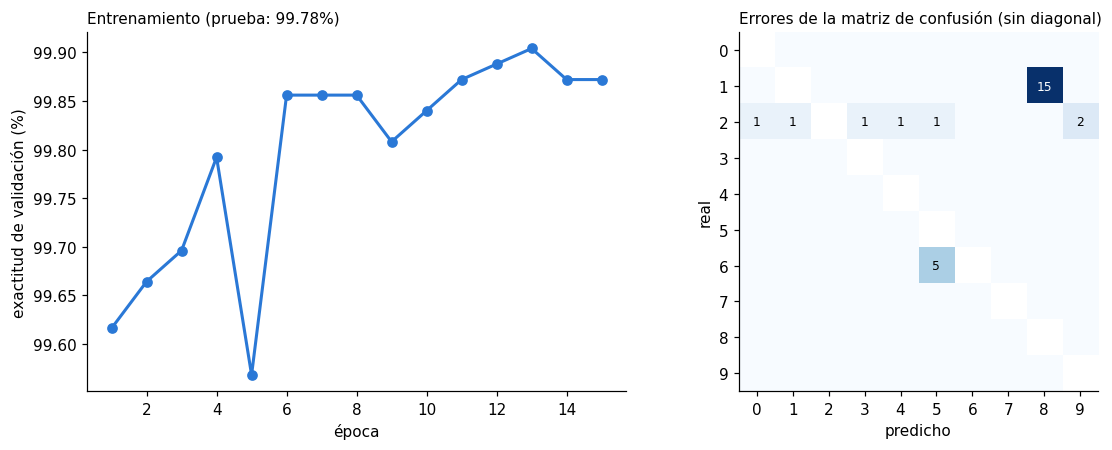

In [4]:
report = json.load(open("models/digit_cnn.json", encoding="utf-8"))
hist = report["history"]
cm = np.array(report["confusion"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot([h["epoch"] for h in hist], [100 * h["val_acc"] for h in hist], color="#2a78d6", marker="o", lw=2)
axes[0].set_xlabel("época"); axes[0].set_ylabel("exactitud de validación (%)")
axes[0].set_title(f"Entrenamiento (prueba: {report['test_acc']:.2%})", fontsize=10, loc="left")
off = cm.astype(float).copy(); np.fill_diagonal(off, np.nan)
im = axes[1].imshow(off, cmap="Blues")
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j]:
            axes[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                         color="white" if cm[i, j] > np.nanmax(off) / 2 else "black")
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
axes[1].set_xlabel("predicho"); axes[1].set_ylabel("real")
axes[1].set_title("Errores de la matriz de confusión (sin diagonal)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

## CNN propia frente a OCR preentrenados

In [5]:
path = Path("outputs/eval_vision/ocr_baselines.json")
if path.exists():
    base = json.load(open(path, encoding="utf-8"))
    print(f"{base['clues']} pistas de {base['n_images']} imágenes\n")
    print(f"{'motor':<11}{'exactitud':>10}{'imposibles':>12}{'ms/pista':>10}")
    for r in base["results"]:
        print(f"{r['engine']:<11}{r['accuracy']:>10.2%}{r['invalid']:>12.2%}{r['ms_per_clue']:>10.1f}")
else:
    print("Ejecutar: python -m src.eval.ocr_baselines --n 60  (requiere requirements-baselines.txt)")

1308 pistas de 60 imágenes

motor       exactitud  imposibles  ms/pista
cnn           100.00%       0.00%       1.1
easyocr        95.41%       3.44%       5.0


## Solver

In [6]:
import csv
summary = Path("outputs/bench/solver_summary.csv")
if summary.exists():
    rows = list(csv.DictReader(open(summary, encoding="utf-8")))
    print(f"{'variante':<9}{'búsqueda':<12}{'mediana ms':>11}{'máx ms':>9}{'sin terminar':>14}")
    for v in ("M1", "M2", "M3"):
        for s in ("auto", "min_domain"):
            g = [r for r in rows if r["variant"] == v and r["search"] == s]
            t = [float(r["time_ms_median"]) for r in g]
            print(f"{v:<9}{s:<12}{np.median(t):>11.1f}{max(t):>9.0f}{sum(r['status'] != 'OPTIMAL' for r in g):>14}")
else:
    print("Ejecutar: python -m src.eval.bench_solver")

variante búsqueda     mediana ms   máx ms  sin terminar


M1       auto               75.6     3104             0
M1       min_domain         57.5    20002             1
M2       auto               62.4     1785             0
M2       min_domain         56.2     1484             0
M3       auto              112.2     1758             0
M3       min_domain        101.0     1267             0
